In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('logs/session_20250630-151446/session.csv')
data

,request_arrival_time,response_output_time,preprocess_start_time,inference_start_time,inference_end_time,postprocess_start_time,client_request_send_time,round_trip_time,latency_request_send,latency_response_receive,server_processing_duration
0,80468.068642,80469.726536,80468.068727,80468.148578,80469.715710,80469.715710,446391.246488,2.289656,-365923.177846,365923.809608,1.657894
1,80470.338453,80471.447637,80470.338586,80470.345508,80471.436580,80471.436580,446393.536163,1.717682,-365923.197710,365923.806209,1.109184
2,80472.399237,80473.604963,80472.399285,80472.406658,80473.594054,80473.594054,446395.507578,1.903802,-365923.108341,365923.806417,1.205726
3,80474.549093,80475.584487,80474.549153,80474.557559,80475.574354,80475.574355,446397.642429,1.748984,-365923.093336,365923.806927,1.035394
4,80476.572737,80478.089192,80476.572847,80476.580420,80478.076505,80478.076506,446399.774117,2.128634,-365923.201380,365923.813560,1.516455
5,80478.721279,80480.038169,80478.721378,80478.723458,80480.024322,80480.024322,446401.911209,1.939845,-365923.189929,365923.812885,1.316889
6,80480.850870,80482.061515,80480.850927,80480.859064,80482.049032,80482.049032,446404.050151,2.107259,-365923.199281,365924.095895,1.210645


In [3]:
# Calculate the duration of each stage by finding the difference between timestamps
data['server_total_duration'] = data['response_output_time'] - data['request_arrival_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']

# This represents network latency plus any other time not captured by the server's timestamps.
data['network_and_other_latency'] = data['round_trip_time'] - data['server_total_duration']

# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_total_duration',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
    'network_and_other_latency'
]]

# Display the calculated durations for each inference request
print("Calculated Durations for Each Request (in seconds):")
display(durations_df)

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("\nSummary Statistics for Durations (in seconds):")
display(durations_df.describe())

Calculated Durations for Each Request (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,network_and_other_latency
0,2.289656,1.657894,1.567132,0.079851,0.010827,0.631762
1,1.717682,1.109184,1.091073,0.006922,0.011056,0.608498
2,1.903802,1.205726,1.187396,0.007373,0.010908,0.698075
3,1.748984,1.035394,1.016796,0.008406,0.010132,0.713590
4,2.128634,1.516455,1.496085,0.007573,0.012686,0.612180
5,1.939845,1.316889,1.300864,0.002080,0.013846,0.622956
6,2.107259,1.210645,1.189968,0.008136,0.012483,0.896614



Summary Statistics for Durations (in seconds):


,round_trip_time,server_total_duration,inference_duration,server_preprocess_duration,server_postprocess_duration,network_and_other_latency
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,1.976552,1.293170,1.264188,0.017191,0.011705,0.683382
std,0.209638,0.222934,0.203909,0.027713,0.001320,0.102948
min,1.717682,1.035394,1.016796,0.002080,0.010132,0.608498
25%,1.826393,1.157455,1.139234,0.007147,0.010867,0.617568
50%,1.939845,1.210645,1.189968,0.007573,0.011056,0.631762
75%,2.117947,1.416672,1.398475,0.008271,0.012585,0.705833
max,2.289656,1.657894,1.567132,0.079851,0.013846,0.896614


Summary Statistics for Durations (in seconds):


,round_trip_time,server_processing_duration,inference_duration,latency_request_send,latency_response_receive,server_preprocess_duration,server_postprocess_duration
count,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
mean,1.976552,1.293170,1.264188,-365923.166832,365923.850214,0.017191,0.011705
std,0.209638,0.222934,0.203909,0.045967,0.108377,0.027713,0.001320
min,1.717682,1.035394,1.016796,-365923.201380,365923.806209,0.002080,0.010132
25%,1.826393,1.157455,1.139234,-365923.198496,365923.806672,0.007147,0.010867
50%,1.939845,1.210645,1.189968,-365923.189929,365923.809608,0.007573,0.011056
75%,2.117947,1.416672,1.398475,-365923.143094,365923.813223,0.008271,0.012585
max,2.289656,1.657894,1.567132,-365923.093336,365924.095895,0.079851,0.013846


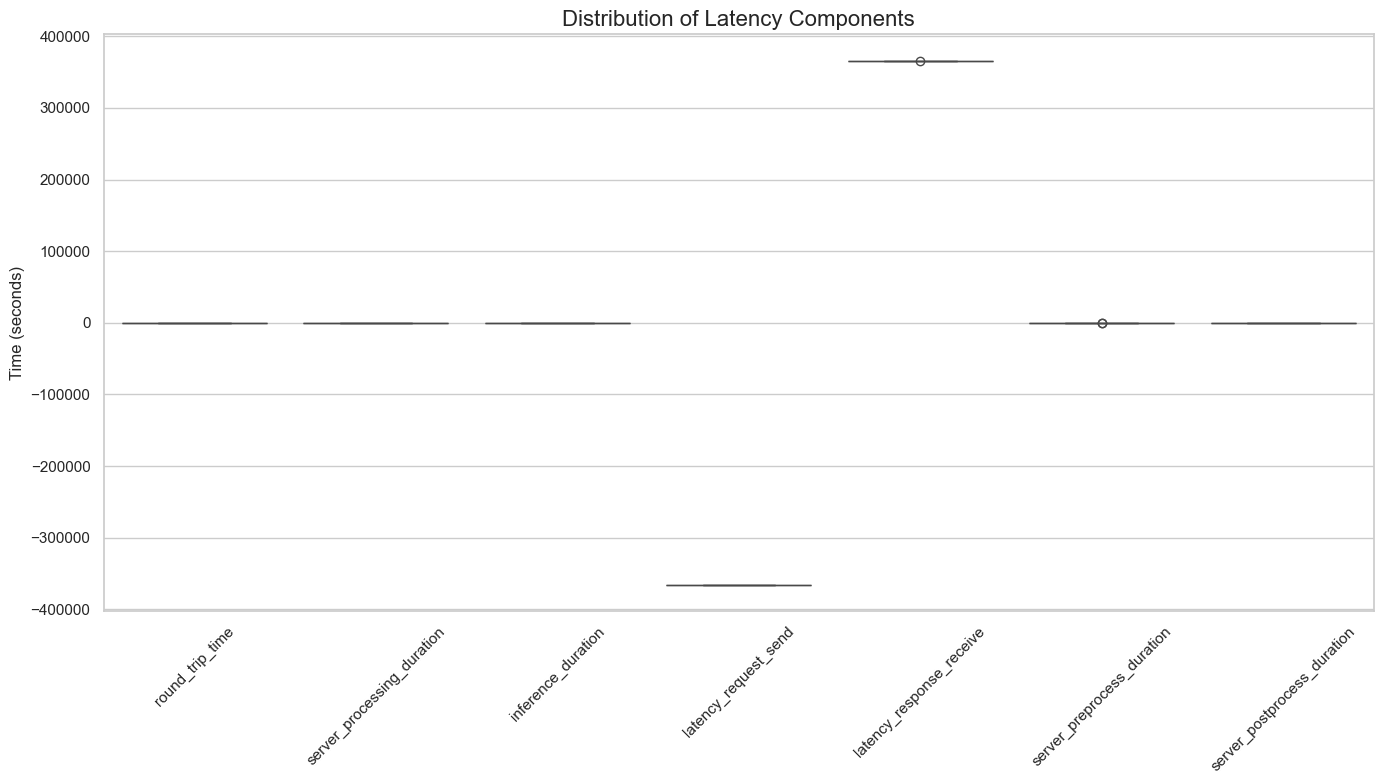

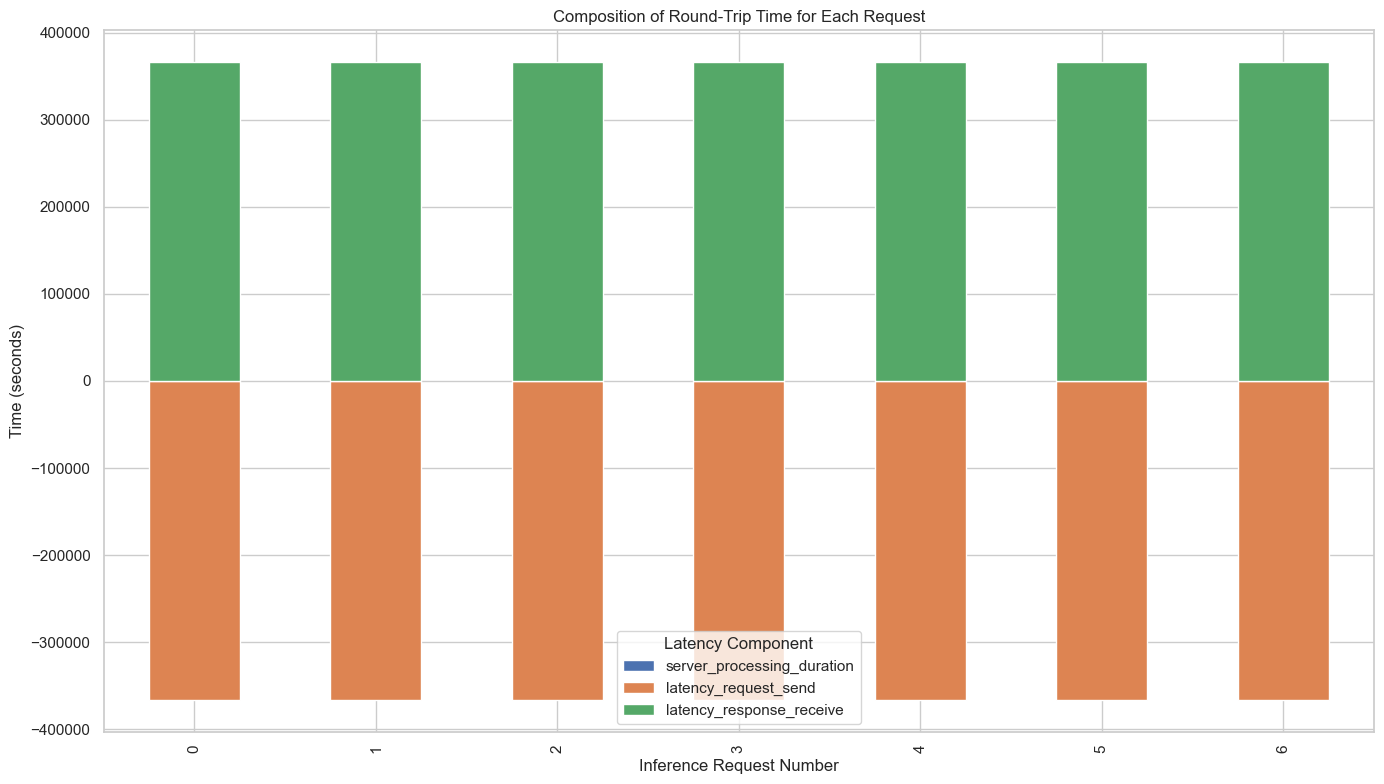

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the duration of each stage by finding the difference between timestamps
data['inference_duration'] = data['inference_end_time'] - data['inference_start_time']
data['server_preprocess_duration'] = data['inference_start_time'] - data['preprocess_start_time']
data['server_postprocess_duration'] = data['response_output_time'] - data['postprocess_start_time']


# Create a new DataFrame containing only the calculated durations for clarity
durations_df = data[[
    'round_trip_time',
    'server_processing_duration',
    'total_network_latency',
    'inference_duration',
    'server_preprocess_duration',
    'server_postprocess_duration',
]].copy()

# Display summary statistics (mean, std, min, max, etc.) for these durations
print("Summary Statistics for Durations (in seconds):")
display(durations_df.describe())

# --- Visualization ---

# Set up the plot style
sns.set_theme(style="whitegrid")

# Create a boxplot to see the distribution of each latency component
plt.figure(figsize=(14, 8))
sns.boxplot(data=durations_df)
plt.xticks(rotation=45)
plt.title('Distribution of Latency Components', fontsize=16)
plt.ylabel('Time (seconds)')
plt.tight_layout()
plt.show()

# Create a stacked bar chart to show the composition of the round-trip time
plot_data = durations_df[[
    'server_processing_duration',
    'total_network_latency'
]].copy()
plot_data.reset_index(inplace=True) # Use the request number as the x-axis

plot_data.plot(
    x='index',
    kind='bar',
    stacked=True,
    figsize=(14, 8),
    title='Composition of Round-Trip Time for Each Request'
)
plt.xlabel("Inference Request Number")
plt.ylabel("Time (seconds)")
plt.legend(title='Latency Component')
plt.tight_layout()
plt.show()